# Homework 2B: Image Filters

<small>v1.1</small>

**DUE DATE**: February 5, 11:59pm Pacific via Canvas

* You can save a copy of this document in your own Drive and work on it in your own Colab
* You can add comments, multiple cells, etc. Just make sure to explain what you did so that we can give you partial credit if necessary
* Make sure to rely only on allowed Python libraries. Each problem will state what's allowed
* When you're done, go to "Runtime > Restart session and run all" to make sure your notebook runs correctly from top to bottom
* **You need to submit two things: an .ipynb and .pdf file.** Go to "File > Download > Download .ipynb" to download the raw Jupyter Notebook file. Then go to "File > Print" and choose "Save as PDF" (or similar). **Make sure the files were produced correctly (sometimes long files get truncated).** We can only grade what you submit. Then upload both files (and the files from HW2A) to the Canvas assignment folder.
* Remember, you are expected to work alone. You can ask questions on Piazza or discuss a solution approach with your peers, but you must not copy their code.
The implementation must be yours. **AI may only be used as outlined in the course's AI-use policy - all AI use must be disclosed below.**

Changelog:
- v1.1: Fixed a typo in the Scharr kernel (all negative signs should be in the same row/column)
- v1.0: Initial version

# AI-Use Disclosure

**You must complete this section to receive a score.**
If you do not submit an AI-use disclosure, your homework will receive **0 points** until a disclosure is provided. Please reply below.

Was AI used? Yes/No

If **Yes**, briefly describe how you used AI (1--3 sentences). Permitted examples include: conceptual clarification, debugging assistance, generating a plot, or rewriting an explanation.

Yes, I used AI for debugging when some of my functions were not working properly, to explain why they were not working.


## 0. Introduction

For those of you who are new to Jupyter Notebook / Google Colab, here's a quick crashcourse.

Colab is a cloud host for [Jupyter Notebook](https://realpython.com/jupyter-notebook-introduction/), allowing you to write Python code in your browser. If you host a Jupyter Notebook locally, you can configure it to run [C++](https://blog.jupyter.org/interactive-workflows-for-c-with-jupyter-fe9b54227d92) or [MATLAB](https://am111.readthedocs.io/en/latest/jmatlab_install.html), too.

The cool thing about Colab is that it comes pre-installed with lots of [libraries for scientific computing](https://stackoverflow.com/questions/47109539/what-are-the-available-libraries-within-google-colaboratory), and it stores a copy of your notebook in GDrive.

One thing to note is that your Notebook will go offline after it stays idle for a while. So every time you open the Notebook (or after time-out), you will have to run all your code cells again (this includes importing your libraries).



### Executing Python code

You can run any valid Python code in the code cells of the Notebook. For example:

In [1]:
2 + 2

4

You can execute the cell by clicking on the "Play" button.

Alternatively, you can use a keyboard shortcut:

- `Ctrl+Enter`: execute the cell
- `Shift+Enter`: execute the cell and select the next cell below it (create one if necessary)

You can see all Keyboard Shortcuts by going to "Tools > Keyboard shortcuts".

Other useful commands include (click into a cell first):

- `Esc+A`: create a cell above the current one
- `Esc+B`: create a cell below the current one
- `Ctrl+M+D`: delete the current cell

Try it!

### Other useful stuff

Colab will give you hints about a function's use. This happens automatically while you're typing. Try it yourself:

First, import NumPy (numerical python, with lots of math functions).
It's customary to import it with an alias "np" so that you don't always have to type "numpy":

In [2]:
import numpy as np

After that, let's try to call the sine function, but let's pretend we forgot what it does. Start typing "np.sin(" but then wait for a second - a window should pop up that shows you the docstring for this function. It will tell you what the function does and which arguments it accepts:

In [3]:
np.sin(0)

np.float64(0.0)

### Important

Jupyter Notebooks use a global workspace. This means that if you define a variable (e.g., `a=1`), then from that point in time forward, `a` will be defined globally in the notebook.

This means that you can (accidentally) define a variable in the last cell of the notebook, and when you re-execute a previous cell, the variable will still be defined. So be careful when designing notebooks to execute stuff from top to bottom.

Before turning something in, it is therefore a good idea to select "Runtime > Restart and run all". This will make sure that your notebook runs correctly top to bottom.

### Loading images

In this assignment, we will be using [scikit-image](https://scikit-image.org/) for our image processing needs.

It comes pre-installed with Colab, so you can just import it.
However, scikit-image is built such that you want to import just the things you need. For example, instead of typing

    import skimage

or even worse:

    from skimage import *

it is customary to import just the functions you need (so as not to clutter up your Python workspace).

There are a number of example images in [skimage.data](https://scikit-image.org/docs/0.3/api/scikits.image.data.html)

In [4]:
from skimage import data as example_images

You might recognize the following picture from lecture. We can use Matplotlib to plot the image (using colormap 'grayscale').

I encourage you to explore the other images in `example_images`.

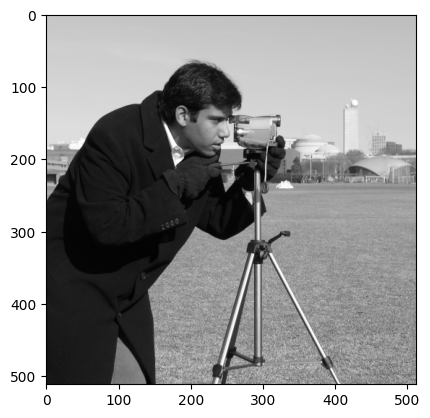

In [5]:
camera_man = example_images.camera()

import matplotlib.pyplot as plt
plt.imshow(camera_man, cmap='gray')

In [6]:
print(camera_man.shape)
print(camera_man)

(512, 512)
[[200 200 200 ... 189 190 190]
 [200 199 199 ... 190 190 190]
 [199 199 199 ... 190 190 190]
 ...
 [ 25  25  27 ... 139 122 147]
 [ 25  25  26 ... 158 141 168]
 [ 25  25  27 ... 151 152 149]]


We can inspect `camera_man` to see that it is a 512x512 grayscale image with gray levels 0-255 (dtype 'uint8'):

In [7]:
camera_man.shape, camera_man.dtype

((512, 512), dtype('uint8'))

# 1. Image Transformations (4 pts)

In this section, you will implement basic image transformations, such as shifting, adjusting brightness and contrast, and correcting color balance.

**Note: The use of functions in scikit-image's `filter` module is not allowed in Section 1.** That would defeat the purpose. Please implement your filters as NumPy arrays. You can use SciPy's [convolve2d](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html) function to convolve them with an image.

## 1.1 **TODO**: Write a kernel that shifts an image 1 pixel up (1 pt)

Give a NumPy array that represents a filter to shift an image upwards by 1 pixel using convolution. Demonstrate your filter on the camera man image from above.

In [8]:
kernel = np.array([[0, 1, 0], [0, 0, 0], [0, 0, 0]])
# kernel = np.array([[0, 0, 0], [0, 0, 0], [0, 1, 0]]) but convolution so flip horizontal + vertical

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

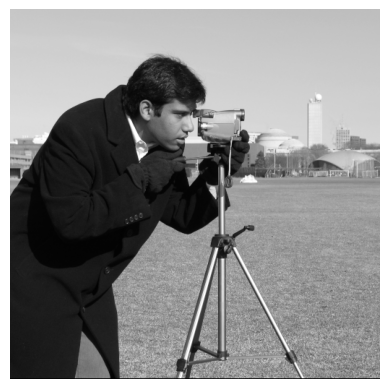

In [9]:
from scipy.signal import convolve2d

conv_img = convolve2d(camera_man, kernel, mode='same')
plt.imshow(conv_img, cmap='gray')
plt.axis('off')

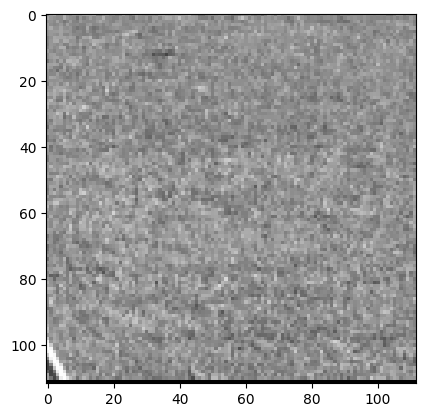

In [10]:
# Zoom in on the bottom-right corner to show that there's a row of
# black pixels at the bottom, but no more black pixels on the right:
plt.imshow(conv_img[400:, 400:], cmap='gray')

## 1.2 **TODO**: Shift an image 2 pixels up & 2 pixels to the left (1 pt)

How would you write a kernel that shifts an image both up and to the left? This time, we want to shift the image 2 pixels up and 2 pixels to the left.

In [11]:
kernel = np.array([[1, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]])
# kernel = np.array([[0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 1]]) but flip

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

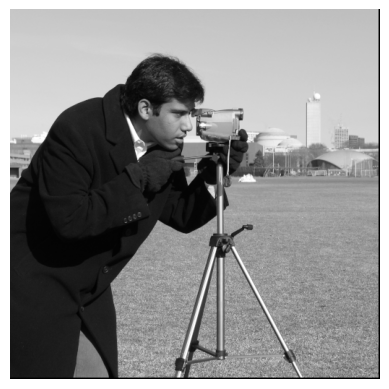

In [12]:
conv_img = convolve2d(camera_man, kernel, mode='same')
plt.imshow(conv_img, cmap='gray')
plt.axis('off')

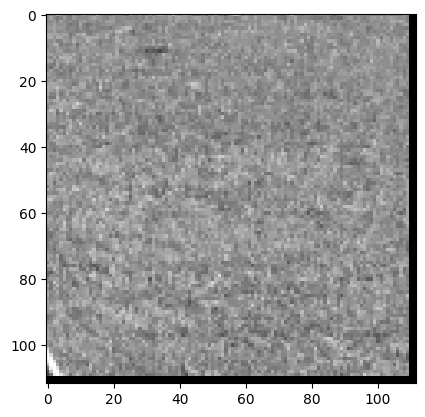

In [13]:
# Zoom in on the bottom-right corner to show that there's now
# a 2px-wide black border:
plt.imshow(conv_img[400:, 400:], cmap='gray')

## 1.3 **TODO**: Brightness adjustment (1 pt)

Adjust the brightness of the camera man image by adding a constant `c` to each pixel value. Make sure the gray levels stay within the valid range.

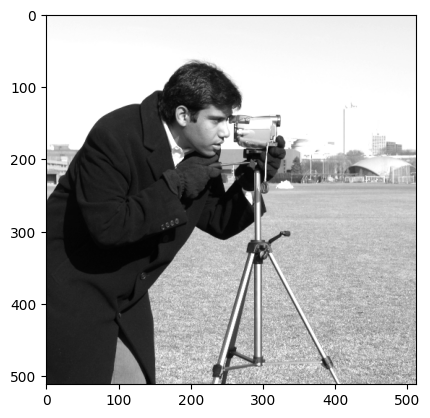

In [14]:
camera_man = example_images.camera()
c = 50

adjusted_img = camera_man.astype(np.float64)
adjusted_img += c
adjusted_img = np.clip(adjusted_img, 0, 255)
adjusted_img = adjusted_img.astype(np.uint8)

plt.imshow(adjusted_img, cmap='gray')

## 1.4 **TODO**: Contrast adjustment (1 pt)

Reduce the contrast of the camera man image by a factor of 2.

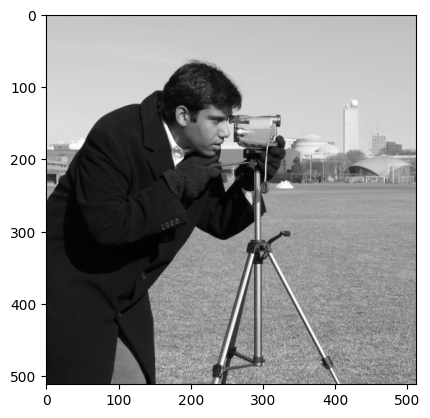

In [15]:
camera_man = example_images.camera()

adjusted_img = camera_man.astype(np.float64)
adjusted_img //= 2
adjusted_img = np.clip(adjusted_img, 0, 255)
adjusted_img = adjusted_img.astype(np.uint8)

plt.imshow(adjusted_img, cmap='gray')

# 2. Edge Detection (10 pts)

In this section, we care about edges.

**Note: The use of functions in scikit-image's `filter` module is not allowed in Section 2.** Again, that would defeat the purpose. Please implement your filters as NumPy arrays. You can use SciPy's [convolve2d](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html) function to convolve them with an image.

*Hint: If you need, you can use ` * ` or `np.multiply` for element-wise multiplicaton of two NumPy arrays. Matrix multiplication can be achieved with the `@` operator.*

## 2.1 **TODO**: Sobel operator (2 pts)

Implement your own Sobel filter using the following steps:

1. (1 point) Implement the horizontal and vertical Sobel filters using the $3\times3$ kernels presented in lecture (you can ignore the scaling factor):
   $$ S_x = \begin{bmatrix} -1 & 0 & 1\\-2 & 0 & 2\\-1 & 0 & 1\end{bmatrix},
   S_y = \begin{bmatrix} 1 & 2 & 1\\0 & 0 & 0\\-1 & -2 & -1\end{bmatrix}.
   $$
3. (1 point) Put the two directional derivatives together to calculate edge magnitude. The result should look qualitatively similar to [`skimage.filters.sobel`](https://scikit-image.org/docs/0.3/api/scikits.image.filter.html#sobel).

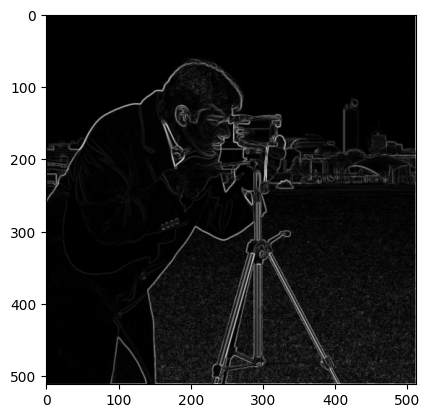

In [16]:
Sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
Sy = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

camera_man = example_images.camera()

x = convolve2d(camera_man, Sx, mode='same')
y = convolve2d(camera_man, Sy, mode='same')
dd = np.sqrt(np.square(x) + np.square(y))

plt.imshow(dd, cmap='gray')

You can compare your result to the one returned by scikit-image.

However, your result will likely be different from the official implementation, because:
- we are operating on ubit images, they are operating on float images
- their filter might use the opposite sign
- they might also normalize the image in an interesting way (we skipped the scaling factor)

But your result should qualitatively look the same as this:

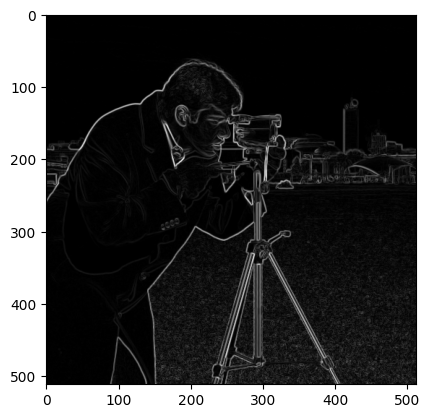

In [17]:
# Compare (qualitatively) to the skimage solution:
from skimage.filters import sobel

camera_man = example_images.camera()
plt.imshow(sobel(camera_man), cmap='gray')

## 2.2 **TODO:** Scharr operator (3 pts)

Now let's compare this to the Scharr operator:

1. (1 point) Implement the horizontal and vertical Scharr filters using the $3\times3$ kernels introduced in lecture:
   $$ K_x = \begin{bmatrix} -3 & 0 & 3\\-10 & 0 & 10\\-3 & 0 & 3\end{bmatrix},
   K_y = \begin{bmatrix} -3 & -10 & -3\\0 & 0 & 0\\3 & 10 & 3\end{bmatrix}.
   $$
2. (1 point) Combine the directional responses to compute the gradient magnitude and visualize them side-by-side.

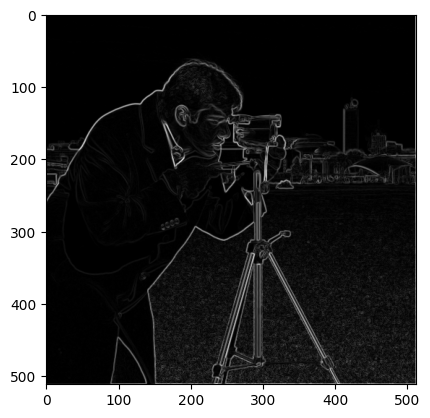

In [18]:
Sx = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]])
Sy = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]])

camera_man = example_images.camera()
x = convolve2d(camera_man, Sx, mode='same')
y = convolve2d(camera_man, Sy, mode='same')
dd = np.sqrt(np.square(x) + np.square(y))

plt.imshow(dd, cmap='gray')

(1 point) How do the Sobel and Scharr edge magnitude images differ? Based on your comparison, why might one prefer Scharr over Sobel in practice?

The Scharr operator has heavier weights in the middle, making it better at responding to angled edges compared to the Sobel operator, which is more sensitive to vertical and horizontal edges but has lower responses to edges captured in the directional derivative. This high accuracy makes the Scharr operator the preferred choice in practice because there is no difference in computations since the filters are both 3x3, we choose the one with better accuracy.

## 2.3 **TODO:** Difference of Gaussians (5 pts)

A Difference of Gaussians (DoG) can be computed by subtracting two blurred versions of an image:
$$\mathrm{DoG}(I) = I * G_{\sigma_1} - I * G_{\sigma_2},$$
where $\sigma_2 > \sigma_1$.

(3 points) First, use `scipy.ndimage.gaussian_filter` to compute two blurred images with $(\sigma_1, \sigma_2)=(1,2)$.
Subtract them to form a DoG image. Visualize side-by-side:
- the image blurred with $\sigma_1$
- the image blurred with $\sigma_2$
- the resulting DoG image

<function matplotlib.pyplot.show(close=None, block=None)>

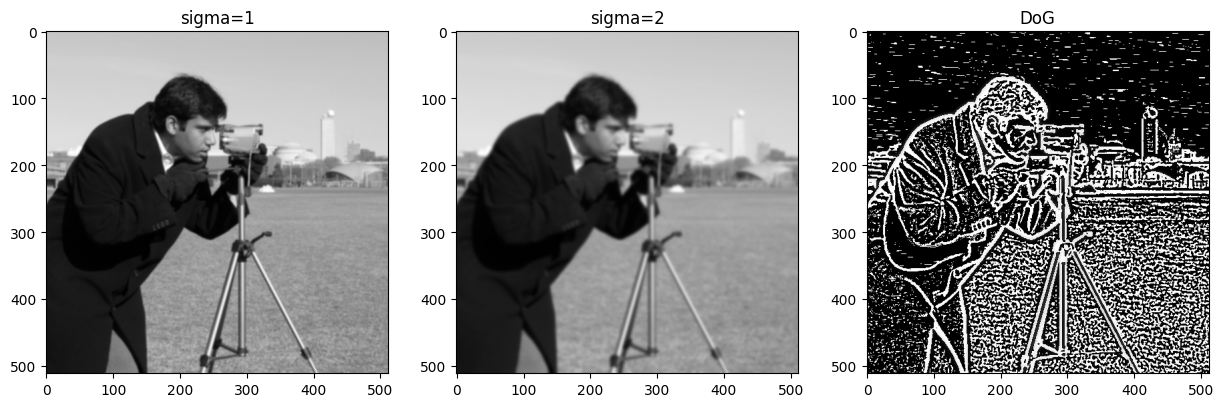

In [19]:
from scipy.ndimage import gaussian_filter

camera_man = example_images.camera()

I1 = gaussian_filter(camera_man, sigma=1)
I2 = gaussian_filter(camera_man, sigma=2)
DoG = I1 - I2

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(I1, cmap='gray')
plt.title("sigma=1")

plt.subplot(1, 3, 2)
plt.imshow(I2, cmap='gray')
plt.title("sigma=2")

plt.subplot(1, 3, 3)
plt.imshow(DoG, cmap='gray')
plt.title("DoG")
plt.show

(2 points) Experiment with different values and ratios for $(\sigma_1, \sigma_2)$.
How does changing $(\sigma_1, \sigma_2)$ affect the result?

The larger the values of sigma 1 and sigma and the larger the difference between sigma 1 and sigma 2 create smoother edges in the DoG image. When sigma 1 = 1 and sigma 2 = 2, the edges are very sharp. When sigma 1 = 1 and sigma 2 = 4, the edges are smoother and wider. When sigma 1 = 5 and sigma 2 = 10, the edges are super smooth and large.

# 3. Canny Edge Detection (6 pts)

Now we want to implement Canny edge detection using `skimage.feature.canny`. You might find [this example](https://scikit-image.org/docs/stable/auto_examples/edges/plot_canny.html) helpful.

Scikit-Image does most of the job for you, but you need to finetune the Canny parameters.

## 3.1 **TODO**: Experiment with the standard deviation of the Gaussian filter (1 pt)

Let's apply Canny to the image of the camera man that we used above.
The first parameter we want to focus on is `sigma`. How does the output change with varying `sigma` values, and why?

Which `sigma` value would you choose for this particular image and why?

<function matplotlib.pyplot.show(close=None, block=None)>

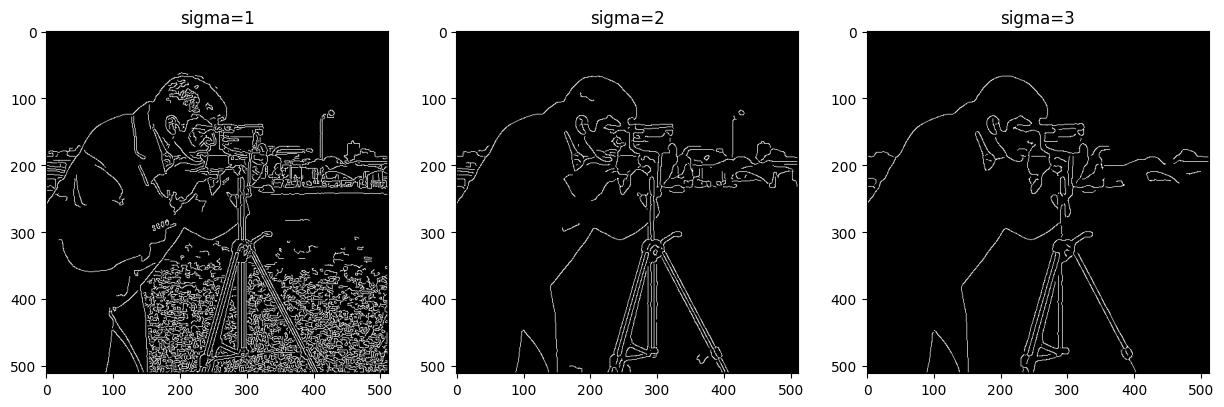

In [20]:
from skimage.feature import canny

camera_man = example_images.camera()
s1 = canny(camera_man, sigma=1)
s2 = canny(camera_man, sigma=2)
s3 = canny(camera_man, sigma=3)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(s1, cmap='gray')
plt.title("sigma=1")

plt.subplot(1, 3, 2)
plt.imshow(s2, cmap='gray')
plt.title("sigma=2")

plt.subplot(1, 3, 3)
plt.imshow(s3, cmap='gray')
plt.title("sigma=3")
plt.show

I would use a sigma value around 2 for the canny operator because it removes some unnecessary edges that jumble the image like the grass which a sigma value of 1 keeps, but keep the important ones like the house in the back, which a sigma value of 3 does not.

How does increasing $\sigma$ affect the sharpness of the edges? At what point do the edges become too smoothed to be useful?

Increasing the value of sigma increases the amount of smoothing used in the canny filter, and that leads to thicker edges and less fine details. At some point, important edges become fine details that are smoothed away, and you lose the main edges in the image.

## 3.2 **TODO**: Experiment with the thresholds (3 pts)

The other two parameters are `high_threshold` and `low_threshold`, which define the upper and lower bound for the hysteresis thresholding, respectively. How does the result change as you vary these two parameters, and why?

Which values would you choose for this particular image and why?

<function matplotlib.pyplot.show(close=None, block=None)>

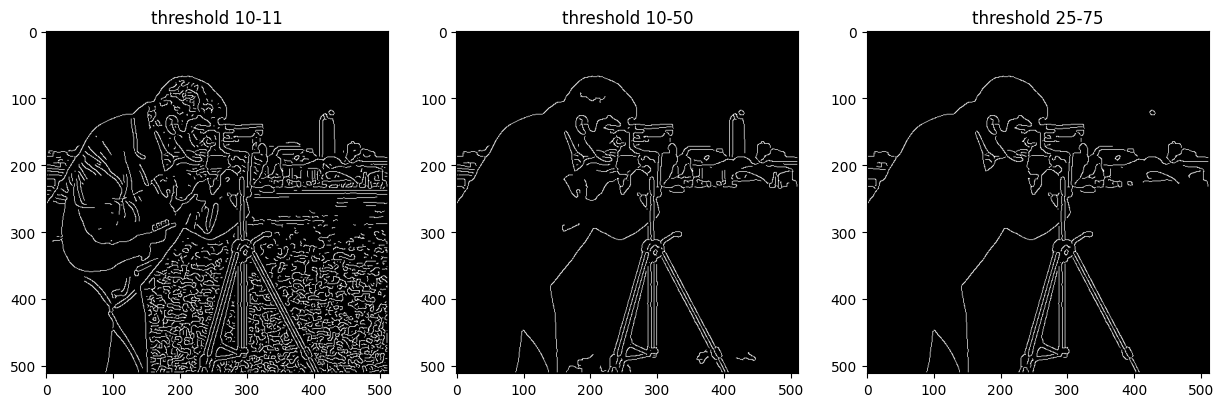

In [21]:
from skimage.feature import canny

camera_man = example_images.camera()
s1 = canny(camera_man, sigma=2, low_threshold=10, high_threshold=11)
s2 = canny(camera_man, sigma=2, low_threshold=10, high_threshold=50)
s3 = canny(camera_man, sigma=2, low_threshold=25, high_threshold=75)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(s1, cmap='gray')
plt.title("threshold 10-11")

plt.subplot(1, 3, 2)
plt.imshow(s2, cmap='gray')
plt.title("threshold 10-50")

plt.subplot(1, 3, 3)
plt.imshow(s3, cmap='gray')
plt.title("threshold 25-75")
plt.show

I think a threshold range from 25 to 75 is good because it removes a lot of fine details that distract from the main parts of the image, while keeping the main parts so you can easily tell the image is a man looking at a camera while also seeing some fine detail of the grass in the back.

What happens to the edges when the thresholds are set too close together or too far apart? How does this affect the quality of edge detection?

When the threshold is too close together, the resulting image is very noisy and hard to interpret, but when the threshold is too far apart, it may miss many details and be too bare.

## 3.3 **TODO**: Compare Canny and Sobel (2 pts)

Using the parameter values you identified above, compare the edges detected by Canny and Sobel. How do they differ? Consider factors like edge smoothness, noise, and the types of edges each method highlights.

The difference is that Canny smoothes first before computing gradients, so the resulting edges are much finer and thinner than in Sobel. The edges produced by the Sobel operator are fuzzier and include more background details, making it still look somewhat like a normal photo.


Which algorithm performs better for detecting finer edges? When might you prefer one method over the other?

I would prefer the canny filter because the resulting image has only important edges that are sharp, preserving only the necessary edges for certain use cases. The resulting image from the Sobel operator still is somewhat indicative of a normal image because the grass edges are fuzzy and you can also see detail edges on the camera.

# 4. Extra Credit (5 pts)

In this extra credit section, you will experiment with adding noise to images and applying different denoising techniques to clean the noisy images. You will then reflect on which denoising method works best in different situations.

## 4.1 **TODO**: Gaussian and salt-and-pepper noise

First, implement two different types of noise (without the help of `skimage.util`):
- Gaussian noise, also known as normal noise, is typically caused by electronic noise in sensors or cameras. It is characterized by a random distribution of pixel intensities, drawn from a normal distribution with Gaussian width `sigma` (you may use `np.random.normal`).
- Salt-and-pepper noise consists of randomly occuring white an black pixels, like "static" on a TV screen. It is usually caused by sharp, sudden disturbances in image signals. Implement this by flipping a fraction `frac` of pixels to either black or white.

For each noise type, write a function that takes as input an image as well as the noise-specific parameters, and outputs a noisy image. Try it on the camera man image.


<function matplotlib.pyplot.show(close=None, block=None)>

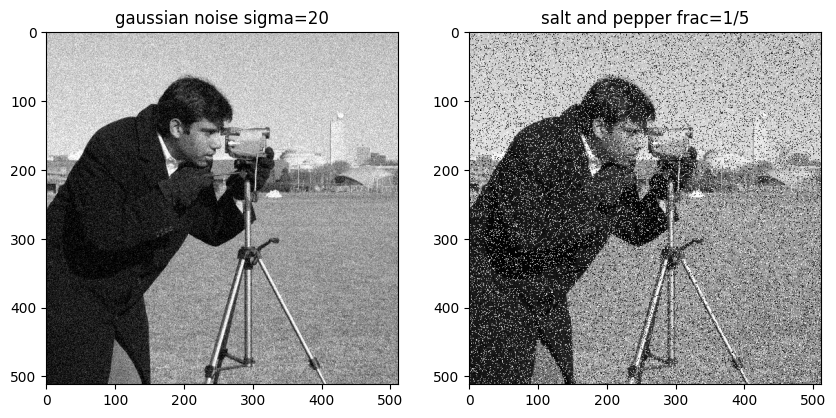

In [22]:
def add_gaussian_noise(img, sigma):
    noise = np.random.normal(0, sigma, img.shape)
    return np.clip(img + noise, 0, 255).astype(np.uint8)

def saltpepper_noise(img, frac):
    h, w = img.shape

    pixels = int(frac * h * w)

    rows = np.random.randint(0, h, pixels)
    cols = np.random.randint(0, w, pixels)
    half = pixels // 2

    for i, (r, c) in enumerate(zip(rows, cols)):
        if i < half:
            img[r, c] = 0
        else:
            img[r, c] = 255

    return img


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
camera_man = example_images.camera()
gn_image = add_gaussian_noise(camera_man, 20)
plt.imshow(gn_image, cmap='gray')
plt.title("gaussian noise sigma=20")

plt.subplot(1, 2, 2)
camera_man = example_images.camera()
spn_image = saltpepper_noise(camera_man, 1/5)
plt.imshow(spn_image, cmap='gray')
plt.title("salt and pepper frac=1/5")

plt.show

## 4.2 **TODO**: Denoising with a median filter

Now that you've applied noise to the image, you will clean it using a median filter. Median filtering works by replacing each pixel value with the median of the intensities in a neighborhood around the pixel. You may use `skimage.filters.median` for this.

Apply the median filter to noisy versions of the camera man images using the two noise types from above. Experiment with different noise settings. Plot the noisy and clean images side by side.

<function matplotlib.pyplot.show(close=None, block=None)>

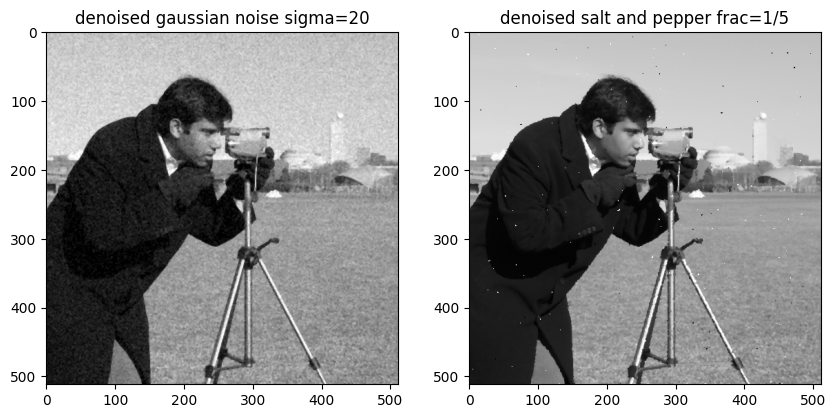

In [23]:
from skimage.filters import median

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
camera_man = example_images.camera()
denoise_gn_image = median(gn_image)
plt.imshow(denoise_gn_image, cmap='gray')
plt.title("denoised gaussian noise sigma=20")

plt.subplot(1, 2, 2)
camera_man = example_images.camera()
denoise_spn_image = median(spn_image)
plt.imshow(denoise_spn_image, cmap='gray')
plt.title("denoised salt and pepper frac=1/5")

plt.show

How effective is the median filter in removing salt-and-pepper noise? Why do you think it works so well (or so poorly)?

The median filter works well with removing salt and pepper noise because it takes the median of a window around each pixel. If the salt and pepper noise fraction is lower such that only a few of the pixels in the window are modified, then it will still be able to find a value close to the original pixel since its neighboring pixels will have roughly the same pixel values. However, if the fraction is too high, then the majority of the pixels in the window can be 0 or 255 and that can skew the median.

How did the median filter perform on the image with Gaussian noise? Is median filtering the best option for this type of noise? If not, what might work better?

Median filter does not perform very well with Gaussian noise because every pixel value is affected by noise so the median of every pixel will be affected slightly. I think techniques like averaging using some normalized values will be better since every pixel has noise.